**Importing Libraries**

In [20]:
import pandas as pd                     #for data manipulation
import numpy as np                      #for data manipulation
import seaborn as sns                   #for visualization
from matplotlib import pyplot as plt    #for visualization

from statsmodels.tsa.api import ExponentialSmoothing, SimpleExpSmoothing, Holt  #for time series analysis
from sklearn.linear_model import LinearRegression                               #for regression analysis

import warnings                                                                 #for ignoring warnings
warnings.filterwarnings("ignore")                                               #ignore warnings


**Import Dataset**

In [21]:
df = pd.read_csv(r"H:\Time Series Analysis\1. Time Series Forecasting\gold_monthly.csv")

In [22]:
df.head()

,Date,Price
0,1950-01,34.73
1,1950-02,34.73
2,1950-03,34.73
3,1950-04,34.73
4,1950-05,34.73


In [23]:
df.tail()

,Date,Price
892,2024-11,2657.0
893,2025-01,2812.5
894,2025-02,2836.8
895,2025-03,3122.8
896,2025-04,3305.0


In [24]:
df.shape

(897, 2)

**EDA**

In [25]:
print(f"Date range of gold prices available from {df.loc[:,'Date'][0]} to {df.loc[:,'Date'][len(df)-1]}")

Date range of gold prices available from 1950-01 to 2025-04


In [29]:
date = pd.date_range(start = '1/1/1950', end = '4/1/2025', freq = 'M')
date

DatetimeIndex(['1950-01-31', '1950-02-28', '1950-03-31', '1950-04-30',
               '1950-05-31', '1950-06-30', '1950-07-31', '1950-08-31',
               '1950-09-30', '1950-10-31',
               ...
               '2024-06-30', '2024-07-31', '2024-08-31', '2024-09-30',
               '2024-10-31', '2024-11-30', '2024-12-31', '2025-01-31',
               '2025-02-28', '2025-03-31'],
              dtype='datetime64[ns]', length=903, freq='ME')

In [30]:
df['month'] = date
df.drop('Date', axis = 1, inplace = True)
df = df.set_index('month')
df.head()

ValueError: Length of values (903) does not match length of index (897)

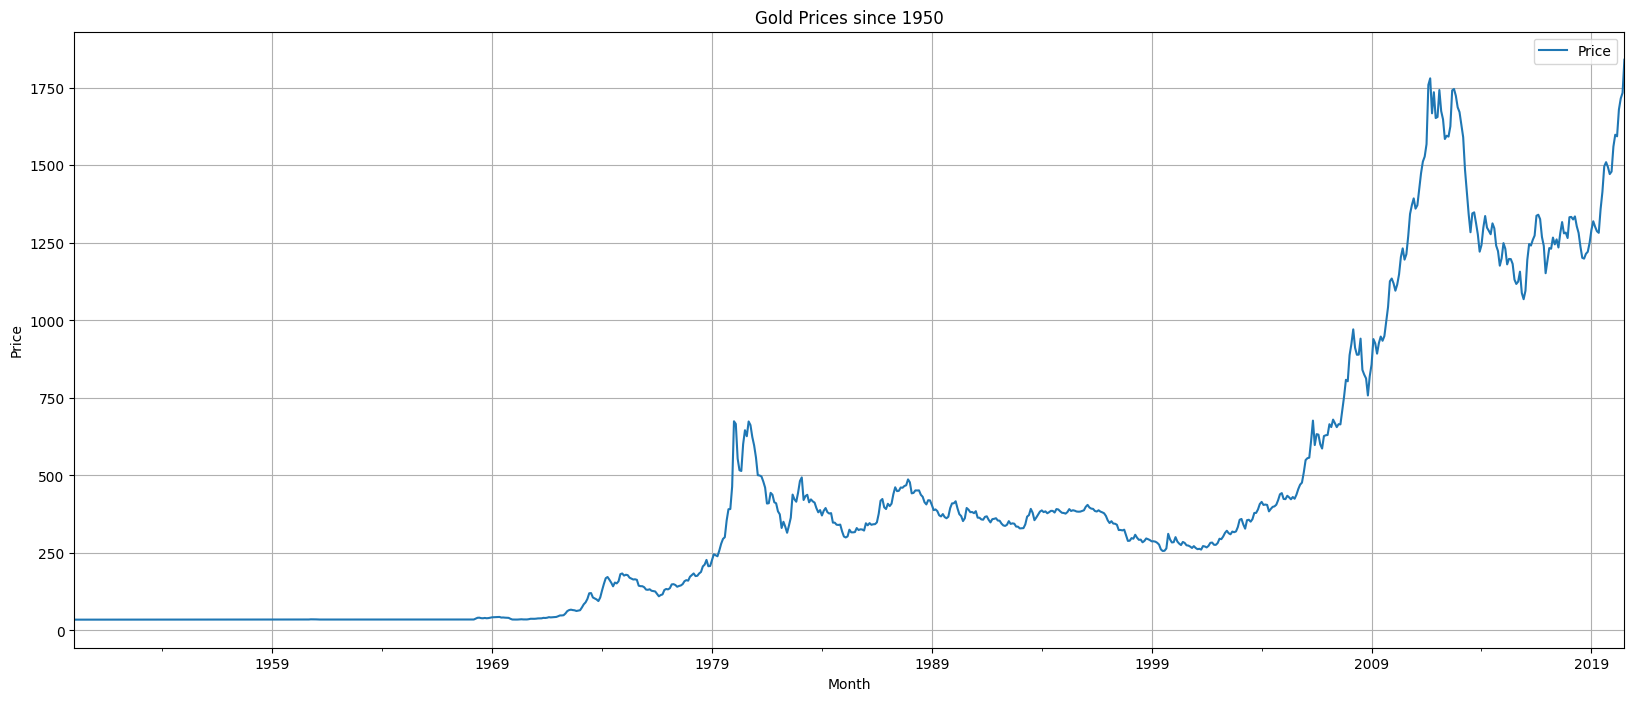

In [ ]:
df.plot(figsize = (20,8))
plt.title('Gold Prices since 1950')
plt.xlabel('Month')
plt.ylabel('Price')
plt.grid()
plt.show()

In [ ]:
round(df.describe(), 3) #summary statistics of the data

,Price
count,847.000
mean,416.557
std,453.665
min,34.490
25%,35.190
50%,319.622
75%,447.029
max,1840.807


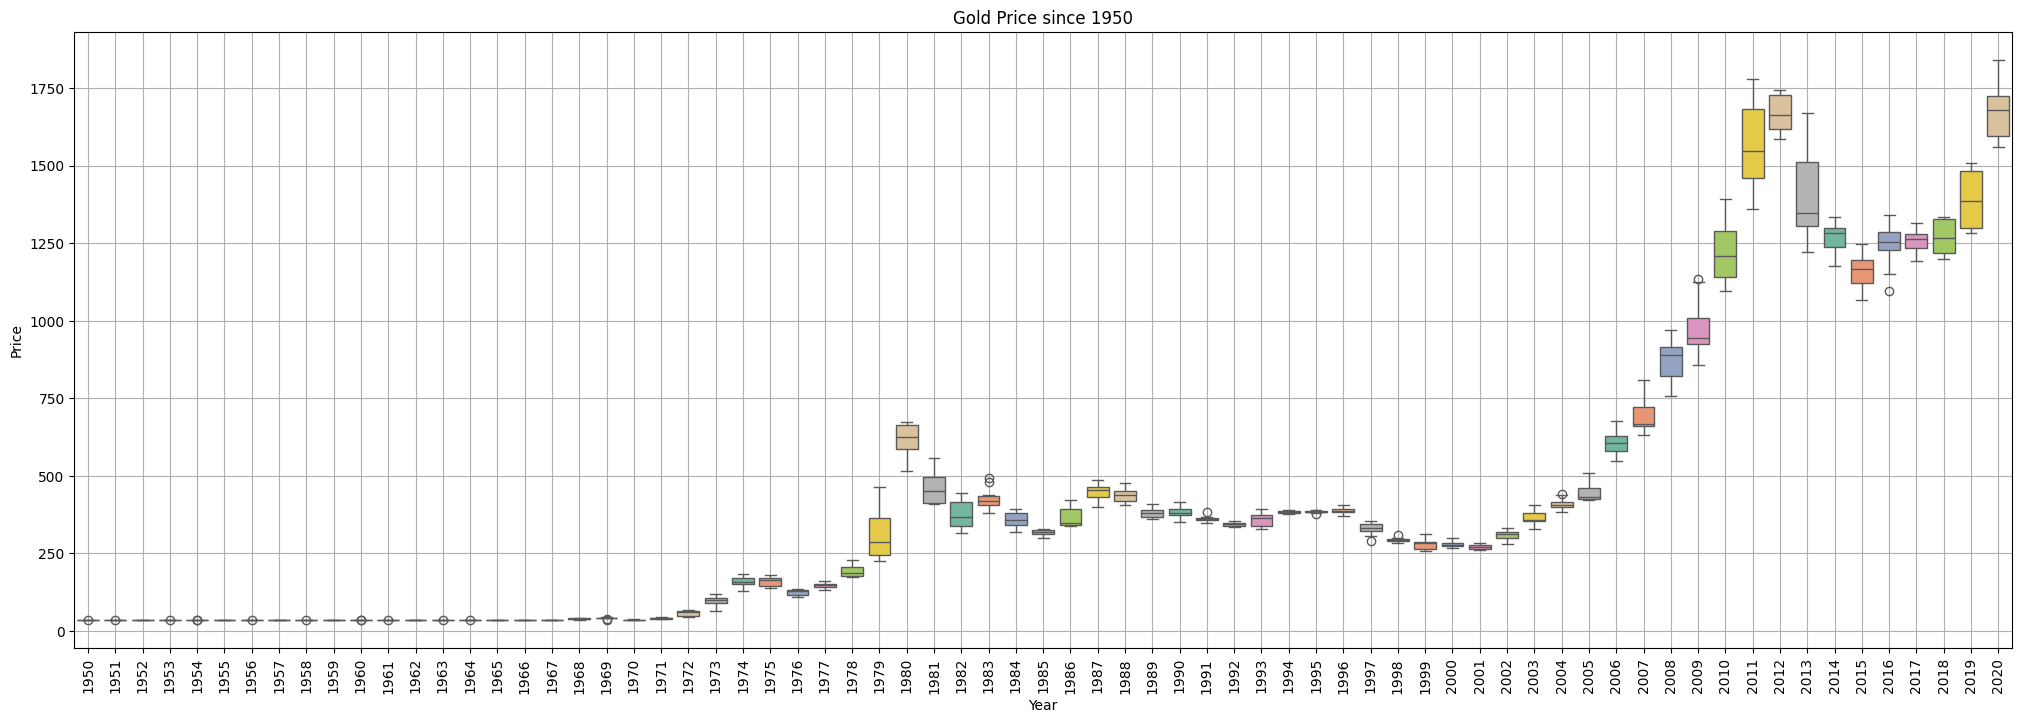

In [ ]:
_, ax = plt.subplots(figsize = (25,8))
sns.boxplot(x = df.index.year, y = df.values[:,0], ax = ax, palette = 'Set2')
plt.title('Gold Price since 1950')
plt.xlabel('Year')
plt.ylabel('Price')
plt.xticks(rotation = 90)
plt.grid()
plt.show();
#The boxplot shows that the gold prices are increasing over the years. The median price is increasing and the interquartile range is also increasing.

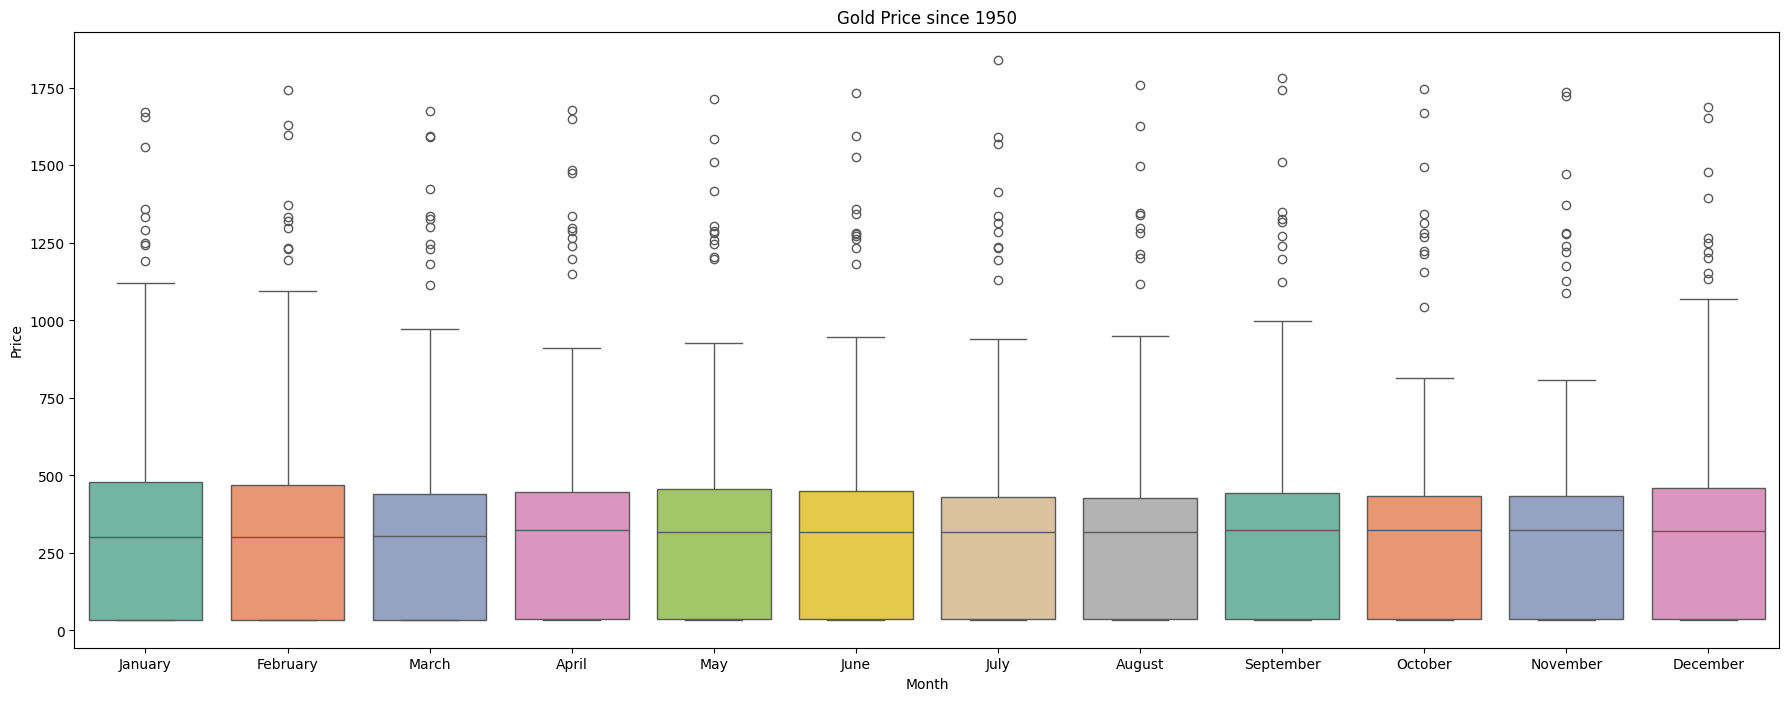

In [ ]:
_, ax = plt.subplots(figsize = (22,8))
sns.boxplot(x = df.index.month_name(), y = df.values[:,0],ax = ax, palette = 'Set2')
plt.title('Gold Price since 1950')
plt.xlabel('Month')
plt.ylabel('Price')
plt.show();
#The boxplot shows that the gold prices are increasing over the years. The median price is increasing and the interquartile range is also increasing.

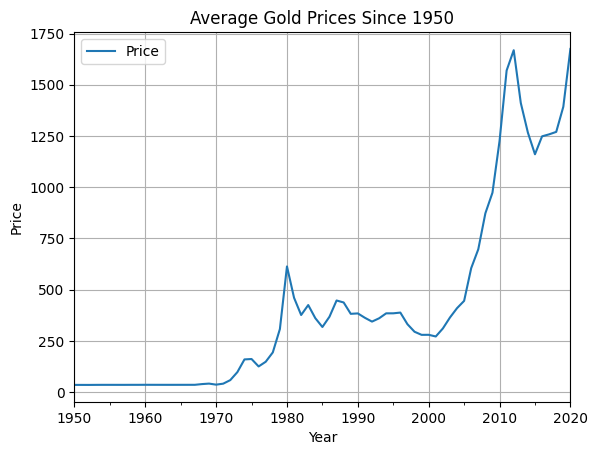

In [ ]:
df_yearly_sum = df.resample('A').mean()
df_yearly_sum.plot();
plt.title('Average Gold Prices Since 1950')
plt.xlabel('Year')
plt.ylabel('Price')
plt.grid()
plt.show()
#The average gold prices are increasing over the years. The median price is increasing and the interquartile range is also increasing.

In [ ]:
import yfinance as yf
import pandas as pd

# Ticker symbol for Gold Futures
gold = yf.Ticker("GC=F")

# Fetch monthly historical data
hist = gold.history(period="max", interval="1mo")

# Save to CSV
hist.to_csv("gold_monthly_data.csv")


In [ ]:
import os
os.getcwd()  # shows your current working directory


'h:\\Time Series Analysis\\1. Time Series Forecasting'